# マルコフ過程を「見て」理解するノートブック

このノートブックは、**マルコフ過程（マルコフ連鎖）** を初めて学ぶ人向けに、
図やアニメーションを使って直感的に理解できるように作っております。

## マルコフ過程とは？

マルコフ過程とは、「次にどうなるか」が **現在の状態だけ** で決まり、
**過去の履歴には依存しない** ような確率的なプロセスのことです。

これを「マルコフ性（Markov property）」と呼びます。

> 例：明日の天気は「今日の天気」だけで決まり、「昨日以前の天気」は関係ない、と仮定するモデル。

このノートブックでは、以下の順番で学びます。

1. 状態と遷移確率の基本（天気の例）
2. 遷移確率行列をヒートマップで可視化
3. 状態遷移図（グラフ）で可視化
4. 実際にランダムにシミュレーションしてみる
5. 時間がたつと確率分布がどう変化するかをアニメーションで見る
6. 最終的に落ち着く先「定常分布」を計算して確認する

それでは始めましょう！

---

# Markov Process Notebook: A Visual Introduction

This notebook is designed for people learning about **Markov processes
(Markov chains)** for the first time, using diagrams and animations to
build an intuitive understanding.

## What is a Markov Process?

A Markov process is a stochastic process in which "what happens next"
is determined **only by the current state**, and **does not depend on
past history**.

This property is called the **Markov property**.

> Example: a model that assumes tomorrow's weather depends only on
> today's weather, and not on the weather from any earlier day.

In this notebook, we will learn in the following order:

1. The basics of states and transition probabilities (weather example)
2. Visualizing the transition matrix as a heatmap
3. Visualizing state transitions as a graph
4. Running an actual random simulation
5. Watching, via animation, how the probability distribution changes over time
6. Computing and confirming the distribution it eventually settles into: the **stationary distribution**

Let's get started!

In [1]:
# 必要なライブラリをインポート
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrowPatch, Circle
import networkx as nx
from IPython.display import HTML

np.random.seed(42)
plt.rcParams['font.size'] = 11

# 日本語のグラフ表示のためのフォント設定
# 環境に日本語フォントが無い場合は文字化けすることがあるので、
# 見つかったものを優先的に使う設定にしています。
import matplotlib.font_manager as fm
candidates = ["Noto Sans CJK JP", "IPAexGothic", "Hiragino Sans", "Yu Gothic", "Meiryo", "MS Gothic"]
available = {f.name for f in fm.fontManager.ttflist}
for name in candidates:
    if name in available:
        plt.rcParams['font.family'] = name
        break
else:
    print("日本語フォントが見つかりませんでした。文字が四角(□)で表示される場合は")
    print("日本語フォント（例: Noto Sans CJK JP）をインストールしてください。")

plt.rcParams['axes.unicode_minus'] = False
print("準備完了！")


日本語フォントが見つかりませんでした。文字が四角(□)で表示される場合は
日本語フォント（例: Noto Sans CJK JP）をインストールしてください。
準備完了！


## 1. 例題：3つの天気の状態

「晴れ（Sunny）」「曇り（Cloudy）」「雨（Rainy）」の3状態からなる
天気のマルコフ連鎖を考えます。

「今日の天気」が分かれば「明日の天気の確率」が決まる、というモデルです。

下の行列 `P` が **遷移確率行列（transition matrix）** です。
`P[i, j]` は「状態 i から状態 j へ移る確率」を表します。

各行の合計は必ず 1 になります（今日の天気から、明日は必ずどれかの天気になるため）。

---

## 1. Example: Three Weather States

Consider a weather Markov chain with three states:
"Sunny", "Cloudy", and "Rainy".

This is a model where knowing "today's weather" determines
"tomorrow's weather probabilities".

The matrix `P` below is the **transition matrix**.
`P[i, j]` represents "the probability of moving from state i to state j".

Each row always sums to 1 (because, starting from today's weather,
tomorrow must be one of the weather states).

In [2]:
states = ["晴れ", "曇り", "雨"]
n = len(states)

# 遷移確率行列（行:今日の状態 → 列:明日の状態）
P = np.array([
    [0.7, 0.2, 0.1],   # 今日が晴れなら
    [0.3, 0.4, 0.3],   # 今日が曇りなら
    [0.2, 0.3, 0.5],   # 今日が雨なら
])

# 各行の合計が1になっているか確認
print("各行の合計:", P.sum(axis=1))
print()
print("遷移確率行列 P:")
for i, s in enumerate(states):
    print(f"  {s}: {P[i]}")


各行の合計: [1. 1. 1.]

遷移確率行列 P:
  晴れ: [0.7 0.2 0.1]
  曇り: [0.3 0.4 0.3]
  雨: [0.2 0.3 0.5]


## 2. 遷移確率行列をヒートマップで見る

数字の羅列だとイメージしづらいので、色の濃淡（ヒートマップ）で
「どの状態からどの状態へ移りやすいか」を可視化します。

色が濃いほど確率が高いことを表します。

---

## 2. Viewing the Transition Matrix as a Heatmap

A list of numbers is hard to picture, so we visualize
"how likely it is to move from one state to another" using shades of
color (a heatmap).

Darker colors represent higher probabilities.

/tmp/ipykernel_1883/808287447.py:19: UserWarning: Glyph 26228 (\N{CJK UNIFIED IDEOGRAPH-6674}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/808287447.py:19: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/808287447.py:19: UserWarning: Glyph 26311 (\N{CJK UNIFIED IDEOGRAPH-66C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/808287447.py:19: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/808287447.py:19: UserWarning: Glyph 38632 (\N{CJK UNIFIED IDEOGRAPH-96E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/808287447.py:19: UserWarning: Glyph 36983 (\N{CJK UNIFIED IDEOGRAPH-9077}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/808287447.py:19: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) 

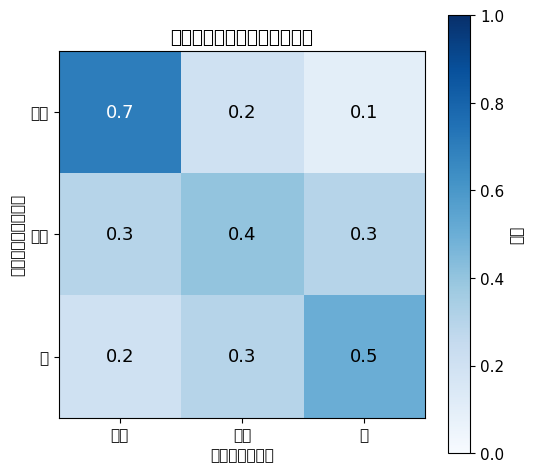

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(P, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(states)
ax.set_yticklabels(states)
ax.set_xlabel("遷移先（明日）")
ax.set_ylabel("現在の状態（今日）")
ax.set_title("遷移確率行列のヒートマップ")

# 各セルに数値を書き込む
for i in range(n):
    for j in range(n):
        color = "white" if P[i, j] > 0.5 else "black"
        ax.text(j, i, f"{P[i, j]:.1f}", ha="center", va="center", color=color, fontsize=13)

fig.colorbar(im, ax=ax, label="確率")
plt.tight_layout()
plt.show()


## 3. 状態遷移図（グラフ）で見る

マルコフ過程を理解する上で一番直感的なのが「状態遷移図」です。

- 丸（ノード）が状態
- 矢印（エッジ）が遷移
- 矢印のそばの数字が遷移確率

矢印の太さも確率の大きさに合わせて変えています。太い矢印ほど起こりやすい遷移です。

---

## 3. Viewing the State Transition Diagram (Graph)

The most intuitive way to understand a Markov process is the
"state transition diagram".

- Circles (nodes) are states
- Arrows (edges) are transitions
- The number next to each arrow is the transition probability

Arrow thickness is also scaled to match the probability — thicker
arrows represent more likely transitions.

/tmp/ipykernel_1883/840454939.py:43: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/840454939.py:43: UserWarning: Glyph 27671 (\N{CJK UNIFIED IDEOGRAPH-6C17}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/840454939.py:43: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/840454939.py:43: UserWarning: Glyph 12510 (\N{KATAKANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/840454939.py:43: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/840454939.py:43: UserWarning: Glyph 12467 (\N{KATAKANA LETTER KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/840454939.py:43: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  plt.tight

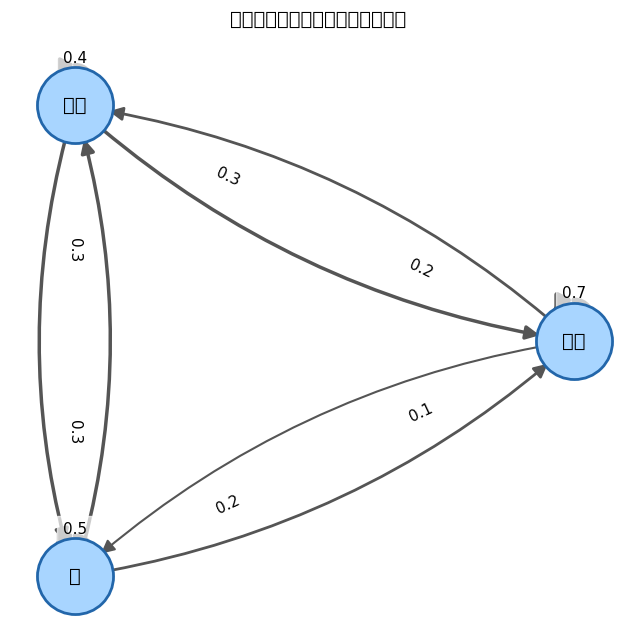

In [4]:
G = nx.DiGraph()
for s in states:
    G.add_node(s)

for i in range(n):
    for j in range(n):
        if P[i, j] > 0:
            G.add_edge(states[i], states[j], weight=P[i, j])

pos = nx.circular_layout(G)

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# ノードを描画
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="#a8d5ff", edgecolors="#2266aa", linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=14, font_weight="bold", ax=ax)

# エッジを描画（自己ループとそれ以外で分ける）
for (u, v, d) in G.edges(data=True):
    w = d["weight"]
    if u == v:
        # 自己ループ
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)], ax=ax,
            connectionstyle="arc3,rad=0.35", width=1 + 4 * w,
            edge_color="#555555", arrowsize=20,
            min_source_margin=25, min_target_margin=25,
        )
    else:
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)], ax=ax,
            connectionstyle="arc3,rad=0.15", width=1 + 5 * w,
            edge_color="#555555", arrowsize=20,
            min_source_margin=25, min_target_margin=25,
        )

edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11,
                              label_pos=0.3, ax=ax, bbox=dict(alpha=0.7, color="white"))

ax.set_title("天気のマルコフ連鎖：状態遷移図", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()


## 4. 実際にシミュレーションしてみる

理屈だけでなく、実際に **サイコロを振るように** ランダムに天気を生成してみましょう。

「今日晴れなら、70%の確率で明日も晴れ、20%の確率で曇り、10%の確率で雨」
というルールに従って、乱数を使って次の状態を決めていきます。

これを何十日分も繰り返し、結果を時系列のグラフで確認します。

---

## 4. Running an Actual Simulation

Beyond the theory, let's actually generate weather at random,
**like rolling a die**.

Following the rule "if it's sunny today, there's a 70% chance it's
sunny again tomorrow, 20% chance of clouds, and 10% chance of rain",
we use random numbers to decide the next state.

We repeat this for dozens of days and check the results on a
time-series chart.

/tmp/ipykernel_1883/1051476348.py:33: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/1051476348.py:33: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/1051476348.py:33: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/1051476348.py:33: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/1051476348.py:33: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/1051476348.py:33: UserWarning: Glyph 27671 (\N{CJK UNIFIED IDEOGRAPH-6C17}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/1051476348.py:33: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from f

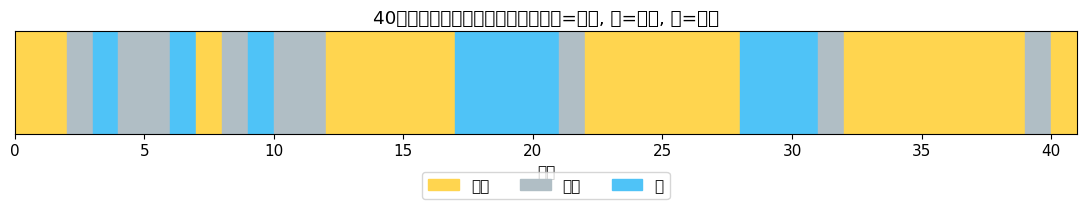

状態の遷移列（数字は状態インデックス 0=晴れ,1=曇り,2=雨）:
[0 0 1 2 1 1 2 0 1 2 1 1 0 0 0 0 0 2 2 2 2 1 0 0 0 0 0 0 2 2 2 1 0 0 0 0 0
 0 0 1 0]


In [5]:
def simulate_markov_chain(P, start_state_idx, n_steps, rng=None):
    '''マルコフ連鎖を n_steps ステップ分シミュレーションする'''
    if rng is None:
        rng = np.random.default_rng(0)
    n_states = P.shape[0]
    trajectory = [start_state_idx]
    current = start_state_idx
    for _ in range(n_steps):
        current = rng.choice(n_states, p=P[current])
        trajectory.append(current)
    return np.array(trajectory)

rng = np.random.default_rng(7)
n_days = 40
trajectory = simulate_markov_chain(P, start_state_idx=0, n_steps=n_days, rng=rng)

colors_map = {0: "#ffd54f", 1: "#b0bec5", 2: "#4fc3f7"}  # 晴れ, 曇り, 雨
fig, ax = plt.subplots(figsize=(11, 2.5))

for day, s_idx in enumerate(trajectory):
    ax.add_patch(plt.Rectangle((day, 0), 1, 1, color=colors_map[s_idx]))

ax.set_xlim(0, len(trajectory))
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("日数")
ax.set_title("40日分の天気シミュレーション（黄=晴れ, 灰=曇り, 青=雨）")

# 凡例
handles = [plt.Rectangle((0, 0), 1, 1, color=colors_map[i]) for i in range(n)]
ax.legend(handles, states, loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3)

plt.tight_layout()
plt.show()

print("状態の遷移列（数字は状態インデックス 0=晴れ,1=曇り,2=雨）:")
print(trajectory)


## 5. 確率分布が時間とともにどう変化するか（アニメーション）

1回のシミュレーションだけでなく、「もし今日が確実に晴れだとしたら、
n日後にはそれぞれの天気になっている確率は何％か？」を計算してみます。

これは、状態の確率分布ベクトル $\pi_t$ に対して

$$ \pi_{t+1} = \pi_t P $$

を繰り返し適用することで計算できます。

下のアニメーションでは、日を追うごとに確率分布（棒グラフ）がどう変化し、
最終的にある形に落ち着いていく様子を見ることができます。

---

## 5. How the Probability Distribution Changes Over Time (Animation)

Beyond a single simulation run, let's calculate: "if today is
certainly sunny, what is the probability of each weather state
n days from now?"

This can be computed by repeatedly applying

$$ \pi_{t+1} = \pi_t P $$

to the state probability distribution vector $\pi_t$.

In the animation below, you can watch how the probability
distribution (bar chart) changes day by day, eventually settling
into a fixed shape.

In [6]:
n_frames = 25
pi0 = np.array([1.0, 0.0, 0.0])  # 初日は確実に「晴れ」

distributions = [pi0]
pi = pi0.copy()
for _ in range(n_frames):
    pi = pi @ P
    distributions.append(pi)
distributions = np.array(distributions)

fig, ax = plt.subplots(figsize=(6, 4.5))
bar_colors = ["#ffb300", "#90a4ae", "#29b6f6"]
bars = ax.bar(states, distributions[0], color=bar_colors)
ax.set_ylim(0, 1)
ax.set_ylabel("確率")
title = ax.set_title("Day 0 の確率分布（初日は必ず晴れからスタート）")

def update(frame):
    for bar, h in zip(bars, distributions[frame]):
        bar.set_height(h)
    title.set_text(f"Day {frame} の確率分布")
    return list(bars) + [title]

ani = animation.FuncAnimation(fig, update, frames=len(distributions), interval=300, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())


/tmp/ipykernel_1883/1368943813.py:26: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  HTML(ani.to_jshtml())
/tmp/ipykernel_1883/1368943813.py:26: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  HTML(ani.to_jshtml())
/tmp/ipykernel_1883/1368943813.py:26: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  HTML(ani.to_jshtml())
/tmp/ipykernel_1883/1368943813.py:26: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  HTML(ani.to_jshtml())
/tmp/ipykernel_1883/1368943813.py:26: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  HTML(ani.to_jshtml())
/tmp/ipykernel_1883/1368943813.py:26: UserWarning: Glyph 26228 (\N{CJK UNIFIED IDEOGRAPH-6674}) missing from font(s) DejaVu Sans.
  HTML(ani.to_jshtml())
/tmp/ipykernel_1883/1368943813.py:26: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER R

## 6. 定常分布（Stationary Distribution）

上のアニメーションを見ると、日数が経つにつれて確率分布があまり変化しなくなり、
ある一定の値に落ち着いていくのが分かります。

この「落ち着く先」の分布を **定常分布** と呼びます。定常分布 $\pi^*$ は

$$ \pi^* = \pi^* P $$

を満たすベクトルで、これは行列 $P^T$ の固有値 1 に対応する固有ベクトルとして計算できます。

シミュレーションで求めた「収束後の分布」と、数学的に計算した定常分布が
一致することを確認してみましょう。

---

## 6. Stationary Distribution

Looking at the animation above, you can see that as the days pass,
the probability distribution changes less and less, eventually
settling into a fixed set of values.

This distribution it "settles into" is called the
**stationary distribution**. The stationary distribution $\pi^*$ is
a vector satisfying

$$ \pi^* = \pi^* P $$

which can be computed as the eigenvector of the matrix $P^T$
corresponding to eigenvalue 1.

Let's confirm that the "converged distribution" found via simulation
matches the stationary distribution computed mathematically.

数学的に計算した定常分布:
  晴れ: 0.4565
  曇り: 0.2826
  雨: 0.2609

シミュレーション(Day 25)で得られた分布:
  晴れ: 0.4565
  曇り: 0.2826
  雨: 0.2609


/tmp/ipykernel_1883/174416364.py:27: UserWarning: Glyph 26228 (\N{CJK UNIFIED IDEOGRAPH-6674}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/174416364.py:27: UserWarning: Glyph 12428 (\N{HIRAGANA LETTER RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/174416364.py:27: UserWarning: Glyph 26311 (\N{CJK UNIFIED IDEOGRAPH-66C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/174416364.py:27: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/174416364.py:27: UserWarning: Glyph 38632 (\N{CJK UNIFIED IDEOGRAPH-96E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/174416364.py:27: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1883/174416364.py:27: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) 

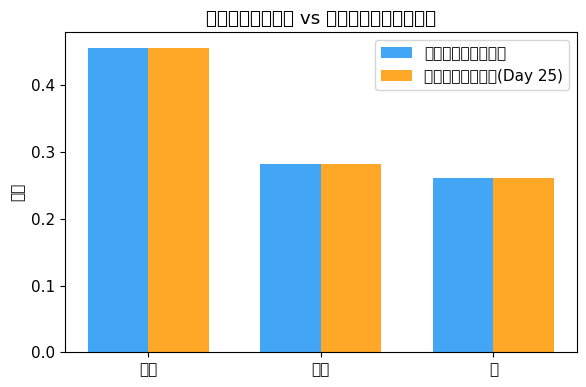

In [7]:
# 固有値・固有ベクトルから定常分布を求める
eigvals, eigvecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigvals - 1))  # 固有値がほぼ1のものを探す
stationary = np.real(eigvecs[:, idx])
stationary = stationary / stationary.sum()  # 合計が1になるよう正規化

print("数学的に計算した定常分布:")
for s, p in zip(states, stationary):
    print(f"  {s}: {p:.4f}")

print()
print("シミュレーション(Day 25)で得られた分布:")
for s, p in zip(states, distributions[-1]):
    print(f"  {s}: {p:.4f}")

# 比較の棒グラフ
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(n)
width = 0.35
ax.bar(x - width/2, stationary, width, label="理論値（定常分布）", color="#42a5f5")
ax.bar(x + width/2, distributions[-1], width, label="シミュレーション(Day 25)", color="#ffa726")
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.set_ylabel("確率")
ax.set_title("定常分布：理論値 vs シミュレーション結果")
ax.legend()
plt.tight_layout()
plt.show()


## 7. 初期状態を変えても同じ場所に収束するか？

マルコフ連鎖の面白い性質の一つは、（一定の条件を満たせば）
**最初にどの状態から始めても、最終的には同じ定常分布に収束する** ということです。

これを確認するために、「晴れから開始」「曇りから開始」「雨から開始」の
3パターンで確率分布の推移を線グラフにして重ねて表示してみます。

---

## 7. Does It Converge to the Same Place Regardless of the Initial State?

One of the interesting properties of a Markov chain is that
(provided certain conditions hold), **no matter which state you
start from, it eventually converges to the same stationary
distribution**.

To confirm this, we'll overlay line charts showing how the
probability distribution evolves for three starting patterns:
"starting from Sunny", "starting from Cloudy", and "starting from
Rainy".

In [ ]:
fig, axes = plt.subplots(1, n, figsize=(14, 4), sharey=True)

for start_idx, ax in enumerate(axes):
    pi0 = np.zeros(n)
    pi0[start_idx] = 1.0
    dists = [pi0]
    pi = pi0.copy()
    for _ in range(20):
        pi = pi @ P
        dists.append(pi)
    dists = np.array(dists)

    for j in range(n):
        ax.plot(dists[:, j], label=states[j], color=bar_colors[j], linewidth=2)
    for j in range(n):
        ax.axhline(stationary[j], color=bar_colors[j], linestyle="--", alpha=0.4)

    ax.set_title(f"開始状態: {states[start_idx]}")
    ax.set_xlabel("日数")
    if start_idx == 0:
        ax.set_ylabel("確率")
    ax.set_ylim(0, 1)

axes[-1].legend(loc="upper right", fontsize=9)
plt.suptitle("どの状態から始めても同じ定常分布（点線）に収束する", y=1.03)
plt.tight_layout()
plt.show()


## まとめ

- マルコフ過程は「次の状態が現在の状態だけで決まる」確率過程
- **遷移確率行列** はヒートマップで、**状態遷移** はグラフ（ノードと矢印）で可視化すると分かりやすい
- 実際にランダムにシミュレーションすることで、理論の動きを体感できる
- 確率分布は時間とともに変化し、多くの場合ある一定の **定常分布** に収束する
- 収束先は初期状態に依存しない（このケースでは）

## 自分で試してみよう（演習）

1. `P` の値を書き換えて、天気がもっと「晴れ続き」になりやすいモデルを作ってみましょう
   （例：晴れから晴れへの確率を 0.9 にするなど）。それによって定常分布がどう変わるか確認してください。
2. 状態を4つ以上に増やして（例：`"晴れ", "曇り", "雨", "雪"`）、同様の可視化を作ってみましょう。
3. `simulate_markov_chain` 関数を使って、シミュレーションを1000回繰り返し、
   各状態に滞在した日数の割合を集計してみましょう。理論上の定常分布と近い値になるはずです。

---

## Summary

- A Markov process is a stochastic process where "the next state is
  determined only by the current state"
- The **transition matrix** is easy to understand as a heatmap, and
  **state transitions** as a graph (nodes and arrows)
- Running an actual random simulation lets you feel the theory in
  motion
- The probability distribution changes over time and, in many cases,
  converges to a fixed **stationary distribution**
- The point of convergence does not depend on the initial state
  (in this case)

## Try It Yourself (Exercises)

1. Rewrite the values of `P` to create a model where the weather is
   more likely to stay "sunny" (e.g., set the sunny-to-sunny
   probability to 0.9). Check how the stationary distribution
   changes as a result.
2. Increase the number of states to four or more (e.g., `"Sunny",
   "Cloudy", "Rainy", "Snowy"`), and build the same kind of
   visualizations.
3. Use the `simulate_markov_chain` function to run the simulation
   1000 times, and tally up the fraction of days spent in each
   state. It should come out close to the theoretical stationary
   distribution.